In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df_index = pd.read_csv('economic_index.csv')

In [29]:
df_index.shape

(24, 6)

In [30]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [31]:
# drop unnecessary columns
df_index.drop(columns=['Unnamed: 0','year','month'], axis=1, inplace=True)

In [32]:
df_index

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [33]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

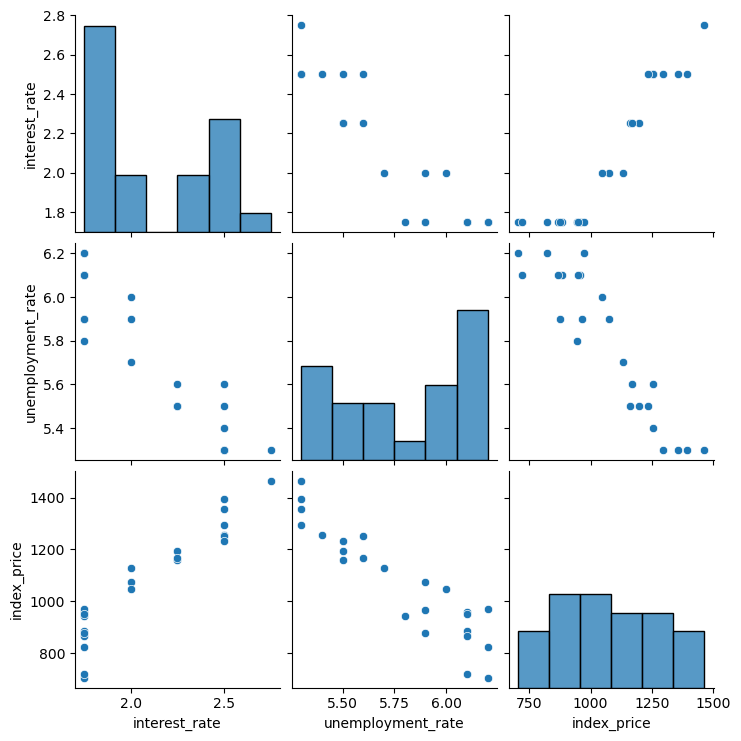

In [34]:
## Visualisation

sns.pairplot(df_index)

In [35]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

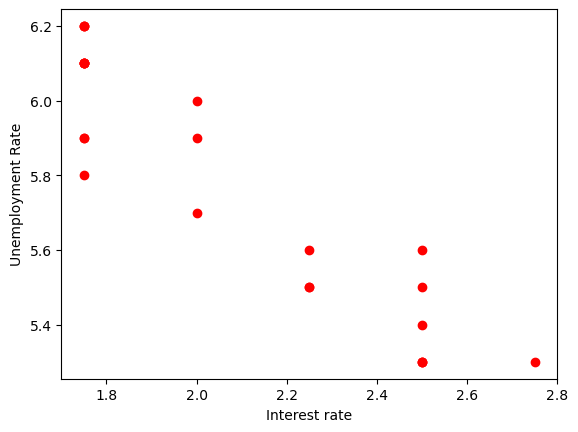

In [36]:
## Visualizing more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel("Unemployment Rate")

In [37]:
## get the independent and dependent features

X = df_index[['interest_rate', 'unemployment_rate']]
# can alsoe be written as 
# X = df_index.iloc[:,:-1]

y = df_index[['index_price']]
# can alsoe be written as 
# y = df_index.iloc[:, -1]

In [38]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [39]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [40]:
# Train Test Split the data 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

<Axes: xlabel='interest_rate', ylabel='index_price'>

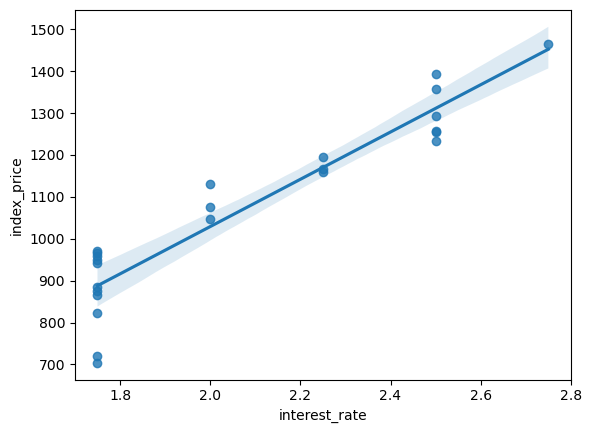

In [ ]:
# regplot is used to plot graph for Linear Regression

sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

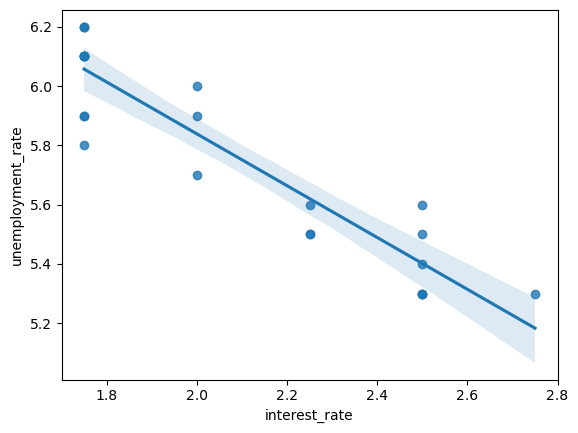

In [42]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [44]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [45]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [46]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [47]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

In [51]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [ ]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [52]:
## prediction 

y_pred = regression.predict(X_test)

In [53]:
y_pred

array([[1180.7466813 ],
       [ 802.74279699],
       [1379.83457045],
       [ 838.52599602],
       [ 973.85313963],
       [1144.96348227]])

In [54]:
# Performance Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306611
73.80444932337099
90.04758423359624


In [58]:
from sklearn.metrics import r2_score

# r square
score = r2_score(y_test, y_pred)
print(score)

# adjusted r square
print(1 - (1-score)* (len(y_test)-1) / (len(y_test) - X_test.shape[1] - 1))

0.7591371539010254
0.5985619231683756


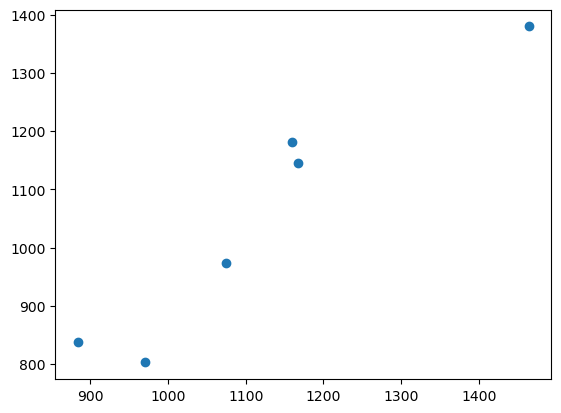

In [59]:
## Assumptions

plt.scatter(y_test, y_pred)


In [60]:
residuals = y_test - y_pred

In [61]:
residuals

,index_price
8,-21.746681
16,168.257203
0,84.165430
18,45.474004
11,101.146860
9,22.036518


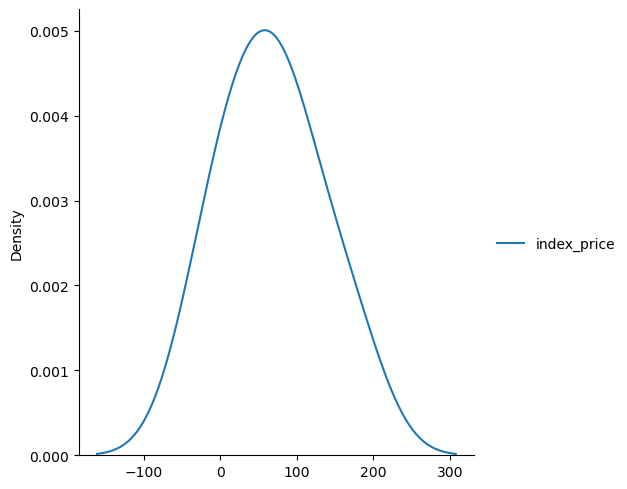

In [62]:
# plot the residuals

sns.displot(residuals, kind='kde')

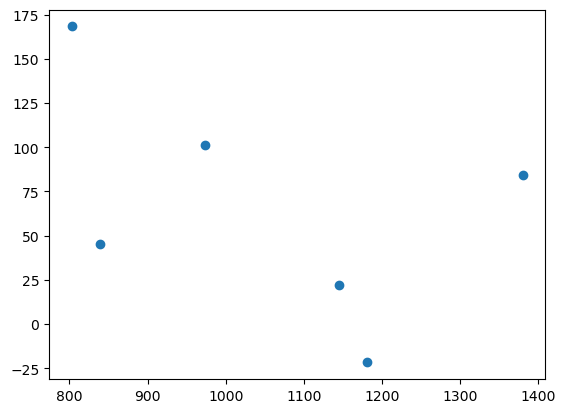

In [63]:
# Scatter plot with respect to predictions and residuals

plt.scatter(y_pred, residuals)

In [64]:
# compute the OLS

import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [66]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 13 Sep 2026   Prob (F-statistic):                       0.754
Time:                        14:08:35   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [67]:
regression.coef_

array([[  88.27275507, -116.25716066]])